# CardioPredict — Notebook de modélisation et prédiction

Ce notebook présente la démarche complète de machine learning utilisée dans le cadre du projet CardioPredict.  
Il couvre la préparation des données, la comparaison de trois modèles de classification, leur évaluation  
rigoureuse et l'analyse des résultats obtenus sur deux datasets distincts.

## Objectifs
- Appliquer un **split train/test 80/20** stratifié sur des données jamais vues au moment du test ;
- Comparer trois modèles de classification : régression logistique, arbre de décision, forêt aléatoire ;
- Quantifier les performances avec des métriques adaptées au contexte médical (ROC-AUC, rappel) ;
- Effectuer une **validation croisée à 5 plis** sur le jeu d'entraînement pour des estimations robustes ;
- Analyser les erreurs de classification du meilleur modèle.

## Datasets utilisés
| Dataset | Source | Observations | Variables |
|---------|--------|-------------|-----------|
| Cardiovascular Disease | Kaggle — Sulianova | 70 000 | 11 |
| Heart Disease | Kaggle — johnsmith88 | 302 (après déduplication) | 13 |

> ⚠️ Les fichiers `cardio.csv` et `heart.csv` doivent être placés dans le même dossier que ce notebook.

## 0. Imports et configuration

In [3]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, balanced_accuracy_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    ConfusionMatrixDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
print("Imports OK")


Imports OK


## 1. Lecture et nettoyage des données

### Format des fichiers
- Séparateur : **point-virgule** `;`
- Certaines colonnes numériques (`weight`, `oldpeak`) peuvent contenir des **virgules décimales** à corriger.
- Le dataset Heart contient **723 lignes dupliquées** sur 1 025 — une déduplication est indispensable  
  pour éviter un *data leakage* (fuite entre train et test) qui gonflerait artificiellement les métriques.

In [4]:
# Lecture des CSV
cardio = pd.read_csv("cardio.csv", sep=";")
heart  = pd.read_csv("heart.csv",  sep=";")

# ── Correction des décimales ────────────────────────────────────────────────
if "weight" in cardio.columns:
    cardio["weight"] = (
        cardio["weight"].astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

if "oldpeak" in heart.columns:
    heart["oldpeak"] = (
        heart["oldpeak"].astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

# ── Suppression des colonnes parasites ─────────────────────────────────────
for col in ["dataset_id", "id"]:
    if col in cardio.columns:
        cardio = cardio.drop(columns=col)

for col in ["cardio_id", "dataset_id", "id_heart", "id"]:
    if col in heart.columns:
        heart = heart.drop(columns=col)

# ── Déduplication du dataset Heart ─────────────────────────────────────────
features_heart = ["age","sex","cp","trestbps","chol","fbs","restecg",
                  "thalach","exang","oldpeak","slope","ca","thal","target"]
n_avant = len(heart)
heart = heart[features_heart].drop_duplicates().reset_index(drop=True)
n_apres = len(heart)
print(f"Heart : {n_avant} lignes → {n_apres} après déduplication ({n_avant - n_apres} doublons supprimés)")

print(f"Cardio : {cardio.shape[0]} observations, {cardio.shape[1]} colonnes")
print(f"Heart  : {heart.shape[0]} observations, {heart.shape[1]} colonnes")

Heart : 1025 lignes → 302 après déduplication (723 doublons supprimés)
Cardio : 70000 observations, 12 colonnes
Heart  : 302 observations, 14 colonnes


## 2. Vérification rapide des données

On vérifie :
- les types de variables et les valeurs manquantes ;
- la répartition des classes (variable cible).

Un déséquilibre important (ex. 90% / 10%) biaiserait les modèles — un rééquilibrage serait alors nécessaire.

In [5]:
print("=== cardio.info() ===")
cardio.info()
print("\nValeurs manquantes cardio :")
display(cardio.isna().sum())

print("\n=== heart.info() ===")
heart.info()
print("\nValeurs manquantes heart :")
display(heart.isna().sum())

=== cardio.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB

Valeurs manquantes cardio :


age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


=== heart.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB

Valeurs manquantes heart :


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
print("Répartition de la cible cardio (0=sain, 1=malade) :")
display(cardio["cardio"].value_counts(normalize=True).rename("proportion").round(4))

print("\nRépartition de la cible heart (1=sain, 0=malade dans ce dataset) :")
display(heart["target"].value_counts(normalize=True).rename("proportion").round(4))

Répartition de la cible cardio (0=sain, 1=malade) :


cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


Répartition de la cible heart (1=sain, 0=malade dans ce dataset) :


target
1    0.543
0    0.457
Name: proportion, dtype: float64

## 3. Préparation des jeux de données

### Split 80 / 20
Le découpage **80 % entraînement / 20 % test** est un choix classique et équilibré :
- il laisse suffisamment de données pour l'apprentissage ;
- il conserve un volume de test suffisant pour une évaluation sérieuse.

Le split est **stratifié** : la proportion de malades / non malades reste identique dans le train et le test.  
La graine `random_state=42` garantit la reproductibilité.

> ⚠️ Le jeu de test reste **totalement à part** jusqu'à l'évaluation finale — il ne sert jamais à choisir les hyperparamètres.

In [7]:
# Séparation features / cible
X_cardio = cardio.drop(columns=["cardio"])
y_cardio = cardio["cardio"]

X_heart = heart.drop(columns=["target"])
y_heart = heart["target"]

# Split 80/20 stratifié
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cardio, y_cardio, test_size=0.2, random_state=42, stratify=y_cardio
)

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

print("Cardio — Train:", Xc_train.shape, "| Test:", Xc_test.shape)
print("Heart  — Train:", Xh_train.shape, "| Test:", Xh_test.shape)

# Vérification absence de chevauchement
overlap_c = len(set(Xc_train.index) & set(Xc_test.index))
overlap_h = len(set(Xh_train.index) & set(Xh_test.index))
print(f"\nChevauchement train/test cardio : {overlap_c} (attendu : 0)")
print(f"Chevauchement train/test heart  : {overlap_h} (attendu : 0)")

Cardio — Train: (56000, 11) | Test: (14000, 11)
Heart  — Train: (241, 13) | Test: (61, 13)

Chevauchement train/test cardio : 0 (attendu : 0)
Chevauchement train/test heart  : 0 (attendu : 0)


## 4. Prétraitement

Le prétraitement est volontairement simple :
- **Imputation médiane** : remplace les éventuelles valeurs manquantes par la médiane de la variable (robuste aux valeurs aberrantes).
- **Standardisation** : centre et réduit chaque variable (moyenne 0, écart-type 1).  
  Indispensable pour la régression logistique, neutre pour les arbres.

Le pipeline est construit avec `ColumnTransformer` pour garantir que le scaler est ajusté uniquement sur le train et appliqué au test.

In [8]:
numeric_features_cardio = X_cardio.columns.tolist()
numeric_features_heart  = X_heart.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

preprocessor_cardio = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features_cardio)]
)

preprocessor_heart = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features_heart)]
)

print("Prétraitement configuré — imputation médiane + standardisation")

Prétraitement configuré — imputation médiane + standardisation


## 5. Modèles testés

Trois algorithmes de classification supervisée sont comparés :

| Modèle | Caractéristiques | Hyperparamètres |
|--------|-----------------|-----------------|
| **Régression Logistique** | Linéaire, interprétable, régularisation L2 | `max_iter=1000` |
| **Arbre de Décision** | Non-linéaire, visualisable | `max_depth=6` (Cardio), `5` (Heart) |
| **Forêt Aléatoire** | Ensemble de 200 arbres, puissant | `n_estimators=200`, `max_depth=10/6` |

In [9]:
models_cardio = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_cardio),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor_cardio),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=6))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_cardio),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1))
    ])
}

models_heart = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_heart),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor_heart),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_heart),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6, n_jobs=-1))
    ])
}

print("Modèles configurés pour les deux datasets.")

Modèles configurés pour les deux datasets.


## 6. Recherche d'hyperparametres ciblee

Objectif : verifier si une optimisation simple ameliore les modeles retenus sans transformer le notebook en benchmark massif.  
La recherche reste volontairement limitee pour garder un temps d'execution raisonnable.

Les meilleurs estimateurs sont ajoutes aux dictionnaires `models_cardio` et `models_heart`, puis compares dans les tableaux de resultats suivants.


In [10]:
def run_random_search(name, pipeline, param_distributions, X_train, y_train, scoring="roc_auc", n_iter=8):
    cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv_tuning,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    search.fit(X_train, y_train)
    print(f"{name} - best CV score ({scoring}): {search.best_score_:.4f}")
    print("Best parameters:", search.best_params_)
    return search

rf_cardio_params = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__max_depth": [6, 8, 10, 12, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

lr_heart_params = {
    "model__C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs", "liblinear"]
}

search_cardio_rf = run_random_search(
    "Cardio - Random Forest",
    models_cardio["Random Forest"],
    rf_cardio_params,
    Xc_train,
    yc_train,
    scoring="roc_auc",
    n_iter=8
)

# For Heart, standard ROC-AUC in sklearn follows target=1. The medical evaluation below uses target=0.
search_heart_lr = run_random_search(
    "Heart - Logistic Regression",
    models_heart["Logistic Regression"],
    lr_heart_params,
    Xh_train,
    yh_train,
    scoring="roc_auc",
    n_iter=8
)

models_cardio["Random Forest tuned"] = search_cardio_rf.best_estimator_
models_heart["Logistic Regression tuned"] = search_heart_lr.best_estimator_


Cardio - Random Forest - best CV score (roc_auc): 0.8024
Best parameters: {'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 10, 'model__class_weight': 'balanced'}
Heart - Logistic Regression - best CV score (roc_auc): 0.9131
Best parameters: {'model__solver': 'lbfgs', 'model__class_weight': None, 'model__C': 0.1}


### Lecture du test d'hyperparametres

Ce test cherche automatiquement de meilleures combinaisons de parametres pour les modeles principaux.  
Pour le Random Forest, il teste notamment le nombre d'arbres, la profondeur maximale et le poids des classes. Pour la regression logistique, il teste la force de regularisation et l'equilibrage des classes.

Le resultat affiche le meilleur score obtenu en validation croisee et les meilleurs parametres trouves. Si le modele optimise ameliore les metriques dans les tableaux suivants, il peut devenir un meilleur candidat. Si le gain est faible, on peut garder le modele initial, plus simple a expliquer.


## 7. Fonction d'evaluation

Les metriques sont adaptees au contexte sante : rappel, specificite, faux negatifs, PR-AUC et ROC-AUC.


In [11]:
def positive_proba(pipeline, X, positive_label=1):
    """Return the probability of the medical positive class."""
    proba = pipeline.predict_proba(X)
    classes = list(pipeline.named_steps["model"].classes_)
    positive_index = classes.index(positive_label)
    return proba[:, positive_index]


def binary_medical_labels(y, positive_label=1):
    """Convert labels to 1 = medical positive class."""
    return (pd.Series(y).to_numpy() == positive_label).astype(int)


def health_metrics(y_true_binary, y_pred_binary, y_proba_positive=None):
    cm = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    row = {
        "Accuracy": round(accuracy_score(y_true_binary, y_pred_binary), 4),
        "Balanced accuracy": round(balanced_accuracy_score(y_true_binary, y_pred_binary), 4),
        "Precision": round(precision_score(y_true_binary, y_pred_binary, zero_division=0), 4),
        "Recall": round(recall_score(y_true_binary, y_pred_binary, zero_division=0), 4),
        "Specificity": round(specificity, 4),
        "F1-Score": round(f1_score(y_true_binary, y_pred_binary, zero_division=0), 4),
        "False positives": int(fp),
        "False negatives": int(fn),
        "True positives": int(tp),
        "True negatives": int(tn),
    }
    if y_proba_positive is not None:
        row["ROC-AUC"] = round(roc_auc_score(y_true_binary, y_proba_positive), 4)
        row["PR-AUC"] = round(average_precision_score(y_true_binary, y_proba_positive), 4)
    else:
        row["ROC-AUC"] = None
        row["PR-AUC"] = None
    return row


def evaluate_models(models, X_train, X_test, y_train, y_test, positive_label=1):
    results = []
    y_test_binary = binary_medical_labels(y_test, positive_label=positive_label)

    for name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        y_pred_raw = pipeline.predict(X_test)
        y_pred_binary = (y_pred_raw == positive_label).astype(int)
        y_proba = positive_proba(pipeline, X_test, positive_label=positive_label)

        row = {"Modele": name}
        row.update(health_metrics(y_test_binary, y_pred_binary, y_proba))
        row["Error rate"] = round(1 - row["Accuracy"], 4)
        row["Errors"] = int((y_pred_binary != y_test_binary).sum())
        results.append(row)

    return pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)


def display_results(df):
    metric_cols = ["Accuracy", "Balanced accuracy", "Precision", "Recall", "Specificity", "F1-Score", "ROC-AUC", "PR-AUC"]
    return df.style.highlight_max(subset=metric_cols, color="#d4edda").highlight_min(
        subset=["False negatives"], color="#d4edda"
    ).format({col: "{:.4f}" for col in metric_cols + ["Error rate"]})


## 8. Resultats - Dataset Cardiovascular


In [12]:
results_cardio = evaluate_models(models_cardio, Xc_train, Xc_test, yc_train, yc_test, positive_label=1)
display(display_results(results_cardio))


,Modele,Accuracy,Balanced accuracy,Precision,Recall,Specificity,F1-Score,False positives,False negatives,True positives,True negatives,ROC-AUC,PR-AUC,Error rate,Errors
0,Random Forest tuned,0.7333,0.7333,0.7597,0.6820,0.7846,0.7187,1509,2225,4771,5495,0.7987,0.7812,0.2667,3734
1,Random Forest,0.7319,0.7318,0.7561,0.6841,0.7796,0.7183,1544,2210,4786,5460,0.7983,0.7806,0.2681,3754
2,Decision Tree,0.7276,0.7275,0.7569,0.6700,0.7851,0.7108,1505,2309,4687,5499,0.7899,0.7655,0.2724,3814
3,Logistic Regression,0.7136,0.7136,0.7314,0.6748,0.7524,0.7020,1734,2275,4721,5270,0.7781,0.7563,0.2864,4009


### Lecture du tableau de resultats Cardio

Ce tableau compare les modeles sur le dataset Cardio.  
La ROC-AUC mesure la capacite generale du modele a separer les profils malades et non malades, tandis que le rappel indique combien de profils malades sont detectes.

Pour un projet sante, il faut lire en priorite le rappel et le nombre de faux negatifs. Un modele avec une accuracy correcte mais trop de faux negatifs serait moins interessant, car il laisserait passer des profils a risque.


### Analyse detaillee du meilleur modele - Cardio


In [13]:
best_name_cardio  = results_cardio.iloc[0]["Modele"]
best_model_cardio = models_cardio[best_name_cardio]
best_model_cardio.fit(Xc_train, yc_train)

yc_true_medical = binary_medical_labels(yc_test, positive_label=1)
yc_proba = positive_proba(best_model_cardio, Xc_test, positive_label=1)
yc_pred = (yc_proba >= 0.5).astype(int)

print(f"Best cardio model: {best_name_cardio}")
print("\nMedical classification report (1 = cardiovascular risk detected):")
print(classification_report(yc_true_medical, yc_pred, target_names=["Not sick", "Sick"], zero_division=0))

cm = confusion_matrix(yc_true_medical, yc_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"True negatives  (TN): {tn}")
print(f"False positives (FP): {fp}")
print(f"False negatives (FN): {fn}  <- sick patients not detected")
print(f"True positives  (TP): {tp}")
print(f"Specificity         : {tn / (tn + fp):.4f}")
print(f"PR-AUC              : {average_precision_score(yc_true_medical, yc_proba):.4f}")


Best cardio model: Random Forest tuned

Medical classification report (1 = cardiovascular risk detected):
              precision    recall  f1-score   support

    Not sick       0.71      0.78      0.75      7004
        Sick       0.76      0.68      0.72      6996

    accuracy                           0.73     14000
   macro avg       0.74      0.73      0.73     14000
weighted avg       0.74      0.73      0.73     14000

True negatives  (TN): 5495
False positives (FP): 1509
False negatives (FN): 2225  <- sick patients not detected
True positives  (TP): 4771
Specificity         : 0.7846
PR-AUC              : 0.7812


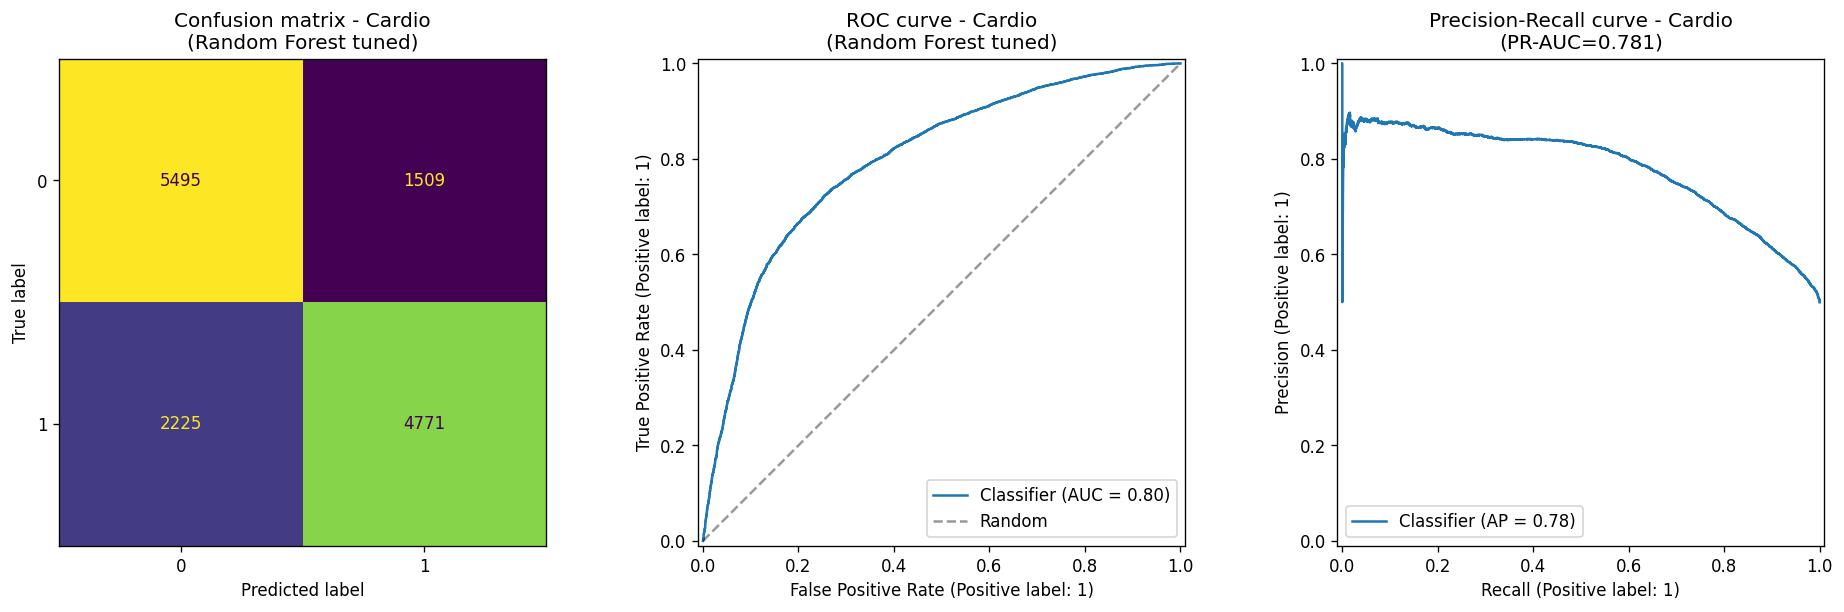

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(yc_true_medical, yc_pred, ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix - Cardio\n({best_name_cardio})")

RocCurveDisplay.from_predictions(yc_true_medical, yc_proba, ax=axes[1])
axes[1].set_title(f"ROC curve - Cardio\n({best_name_cardio})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Random")
axes[1].legend()

PrecisionRecallDisplay.from_predictions(yc_true_medical, yc_proba, ax=axes[2])
axes[2].set_title(f"Precision-Recall curve - Cardio\n(PR-AUC={average_precision_score(yc_true_medical, yc_proba):.3f})")

plt.tight_layout()
plt.show()


## 9. Analyse des erreurs - Cardio


In [15]:
errors_cardio = Xc_test.copy()
errors_cardio["y_true"] = yc_true_medical
errors_cardio["y_pred"] = yc_pred
errors_cardio["proba_positive"] = yc_proba
errors_cardio["correct"] = (errors_cardio["y_true"] == errors_cardio["y_pred"])

def label_error(row):
    if row["y_true"] == 0 and row["y_pred"] == 0: return "True Negative"
    if row["y_true"] == 0 and row["y_pred"] == 1: return "False Positive"
    if row["y_true"] == 1 and row["y_pred"] == 0: return "False Negative"
    return "True Positive"

errors_cardio["error_type"] = errors_cardio.apply(label_error, axis=1)

print("Prediction type distribution:")
display(errors_cardio["error_type"].value_counts())
print(f"\nError rate: {(~errors_cardio['correct']).mean():.4f}")


Prediction type distribution:


error_type
True Negative     5495
True Positive     4771
False Negative    2225
False Positive    1509
Name: count, dtype: int64


Error rate: 0.2667


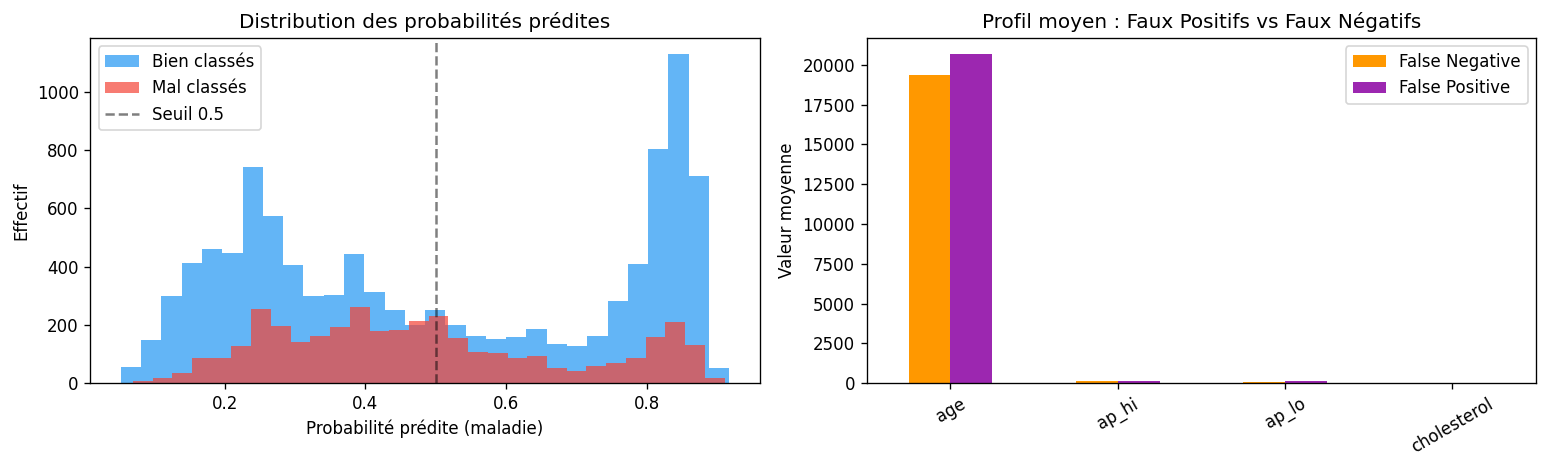


Moyennes par type d'erreur :


,age,ap_hi,ap_lo,cholesterol
error_type,,,,
False Negative,19374.53,117.32,78.21,1.16
False Positive,20661.60,135.13,109.71,1.61


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution des probabilités prédites
axes[0].hist(errors_cardio.loc[errors_cardio["correct"], "proba_positive"],
             bins=30, alpha=0.7, label="Bien classés", color="#2196F3")
axes[0].hist(errors_cardio.loc[~errors_cardio["correct"], "proba_positive"],
             bins=30, alpha=0.7, label="Mal classés", color="#F44336")
axes[0].axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Seuil 0.5")
axes[0].set_xlabel("Probabilité prédite (maladie)")
axes[0].set_ylabel("Effectif")
axes[0].set_title("Distribution des probabilités prédites")
axes[0].legend()

# Comparaison FP vs FN
key_features = ["age", "ap_hi", "ap_lo", "cholesterol"]
summary = (errors_cardio[errors_cardio["error_type"].isin(["False Positive","False Negative"])]
           .groupby("error_type")[key_features].mean().round(2))
summary.T.plot(kind="bar", ax=axes[1], color=["#FF9800","#9C27B0"])
axes[1].set_title("Profil moyen : Faux Positifs vs Faux Négatifs")
axes[1].set_ylabel("Valeur moyenne")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nMoyennes par type d'erreur :")
display(summary)

## 10. Validation croisee - Cardio


ROC-AUC scores by fold: [0.8001 0.8005 0.8044 0.8019 0.8062]
Mean ROC-AUC CV      : 0.8026
Standard deviation   : 0.0026
95% CI on the mean   : [0.8003, 0.8049]

ROC-AUC on test      : 0.7987


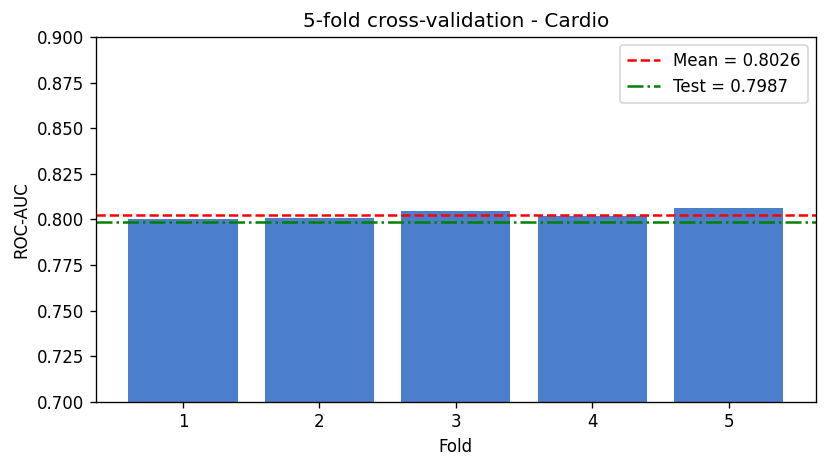

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model_cardio, Xc_train, yc_train,
    cv=cv, scoring="roc_auc", n_jobs=-1
)

mean_cv  = cv_scores.mean()
std_cv   = cv_scores.std(ddof=1)
ci_low   = mean_cv - 1.96 * std_cv / math.sqrt(len(cv_scores))
ci_high  = mean_cv + 1.96 * std_cv / math.sqrt(len(cv_scores))

test_auc = roc_auc_score(yc_true_medical, yc_proba)

print("ROC-AUC scores by fold:", np.round(cv_scores, 4))
print(f"Mean ROC-AUC CV      : {mean_cv:.4f}")
print(f"Standard deviation   : {std_cv:.4f}")
print(f"95% CI on the mean   : [{ci_low:.4f}, {ci_high:.4f}]")
print(f"\nROC-AUC on test      : {test_auc:.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color="#1F5FBF", alpha=0.8)
plt.axhline(mean_cv, color="red", linestyle="--", label=f"Mean = {mean_cv:.4f}")
plt.axhline(test_auc, color="green", linestyle="-.", label=f"Test = {test_auc:.4f}")
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("5-fold cross-validation - Cardio")
plt.legend()
plt.ylim(0.7, 0.9)
plt.tight_layout()
plt.show()


## 11. Importance des variables - Cardio


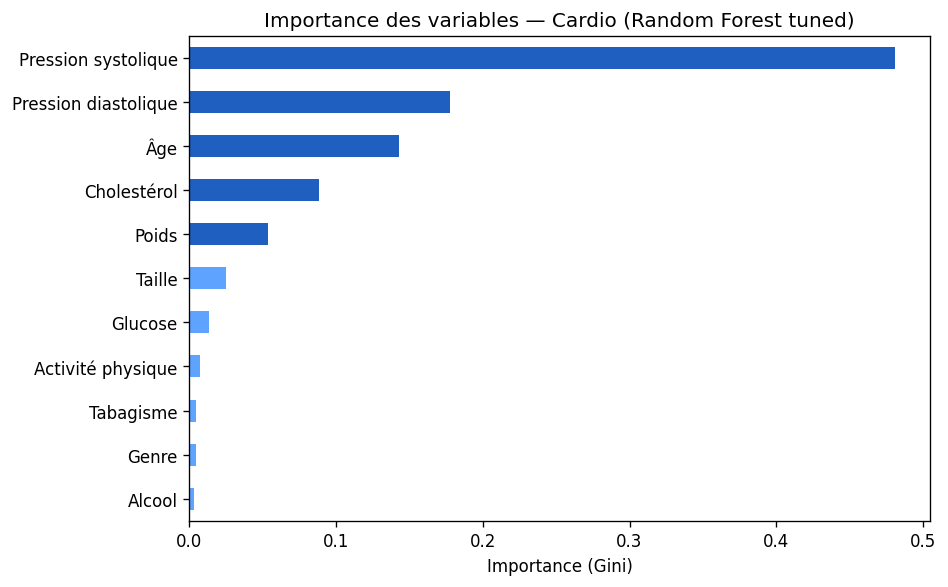

In [18]:
def plot_feature_importance(pipeline, feature_names, title):
    model = pipeline.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_names)
        label_x = "Importance (Gini)"
    elif hasattr(model, "coef_"):
        importances = pd.Series(np.abs(model.coef_[0]), index=feature_names)
        importances = importances / importances.sum()
        label_x = "|Coefficient| normalisé"
    else:
        print("Pas d'importance disponible.")
        return
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    colors = ["#1F5FBF" if v >= importances.quantile(0.6) else "#5EA3FF" for v in importances.values]
    importances.plot(kind="barh", color=colors)
    plt.xlabel(label_x)
    plt.title(title)
    plt.tight_layout()
    plt.show()

labels_fr = {
    "age":"Âge","gender":"Genre","height":"Taille","weight":"Poids",
    "ap_hi":"Pression systolique","ap_lo":"Pression diastolique",
    "cholesterol":"Cholestérol","gluc":"Glucose",
    "smoke":"Tabagisme","alco":"Alcool","active":"Activité physique"
}
feature_names_fr = [labels_fr.get(f, f) for f in X_cardio.columns]

plot_feature_importance(best_model_cardio, feature_names_fr,
                        f"Importance des variables — Cardio ({best_name_cardio})")

### Interpretabilite complementaire - Cardio

L'importance Gini d'une foret aleatoire peut favoriser les variables continues ou tres dispersees.  
On ajoute donc une importance par permutation, qui mesure la baisse de performance lorsque chaque variable est melangee.


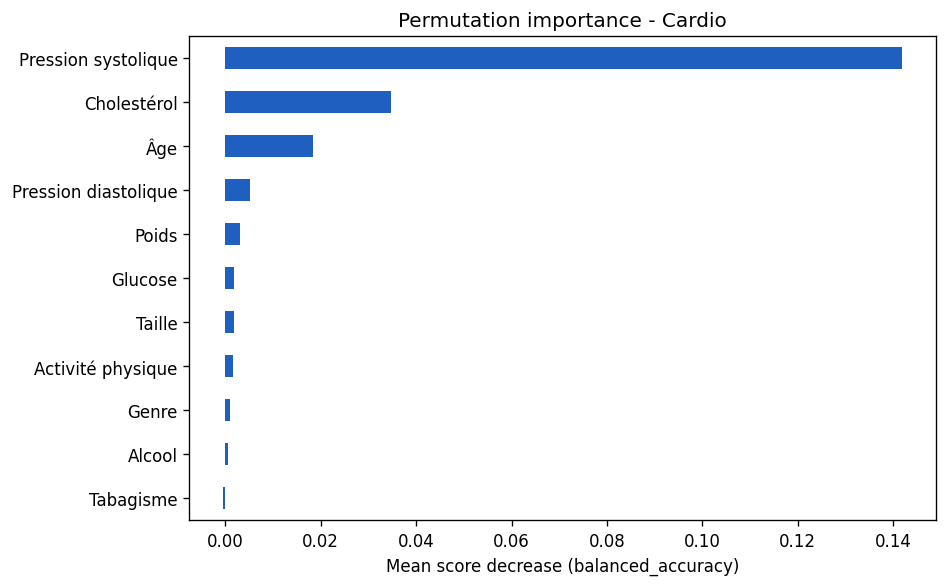

In [19]:
def plot_permutation_importance(pipeline, X_test, y_test, feature_names, title, scoring="balanced_accuracy"):
    result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
        scoring=scoring
    )
    importances = pd.Series(result.importances_mean, index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh", color="#1F5FBF")
    plt.xlabel(f"Mean score decrease ({scoring})")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_permutation_importance(
    best_model_cardio,
    Xc_test,
    yc_test,
    feature_names_fr,
    "Permutation importance - Cardio",
    scoring="balanced_accuracy"
)


### Optimisation du seuil - Cardio

Le seuil par defaut `0.5` est facile a expliquer, mais il peut etre trop strict si l'objectif est de reduire les faux negatifs.  
Plusieurs seuils sont testes pour observer le compromis rappel / precision / specificite.


In [20]:
def threshold_analysis(y_true_binary, y_proba_positive, thresholds=(0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60)):
    rows = []
    for threshold in thresholds:
        y_pred_threshold = (y_proba_positive >= threshold).astype(int)
        row = {"Threshold": threshold}
        row.update(health_metrics(y_true_binary, y_pred_threshold, y_proba_positive=None))
        rows.append(row)
    cols = ["Threshold", "Precision", "Recall", "Specificity", "F1-Score", "False positives", "False negatives", "True positives", "True negatives"]
    return pd.DataFrame(rows)[cols]

cardio_thresholds = threshold_analysis(yc_true_medical, yc_proba)
display(cardio_thresholds.style.highlight_max(subset=["Recall", "F1-Score"], color="#d4edda")
        .highlight_min(subset=["False negatives"], color="#d4edda")
        .format({"Threshold": "{:.2f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "Specificity": "{:.4f}", "F1-Score": "{:.4f}"}))

cardio_candidates = cardio_thresholds[cardio_thresholds["Recall"] >= 0.75]
cardio_threshold_choice = cardio_candidates.sort_values(["False negatives", "False positives"]).iloc[0] if len(cardio_candidates) else None
if cardio_threshold_choice is not None:
    print("Recommended threshold when recall is the priority:")
    display(cardio_threshold_choice.to_frame().T)
else:
    print("No tested threshold reaches the target recall of 0.75.")


,Threshold,Precision,Recall,Specificity,F1-Score,False positives,False negatives,True positives,True negatives
0,0.30,0.6309,0.8796,0.4859,0.7348,3601,842,6154,3403
1,0.35,0.6580,0.8415,0.5631,0.7385,3060,1109,5887,3944
2,0.40,0.6972,0.7854,0.6593,0.7387,2386,1501,5495,4618
3,0.45,0.7319,0.7367,0.7304,0.7343,1888,1842,5154,5116
4,0.50,0.7597,0.6820,0.7846,0.7187,1509,2225,4771,5495
5,0.55,0.7856,0.6311,0.8280,0.6999,1205,2581,4415,5799
6,0.60,0.8045,0.5935,0.8559,0.6831,1009,2844,4152,5995


Recommended threshold when recall is the priority:


,Threshold,Precision,Recall,Specificity,F1-Score,False positives,False negatives,True positives,True negatives
0,0.3,0.6309,0.8796,0.4859,0.7348,3601.0,842.0,6154.0,3403.0


### Lecture du test de seuil Cardio

Ce test change le seuil de decision utilise pour transformer une probabilite en prediction.  
Avec un seuil plus bas, le modele classe plus facilement un patient comme a risque : le rappel augmente souvent, mais les faux positifs peuvent aussi augmenter.

Le resultat permet de choisir un seuil selon l'objectif. Pour une application pedagogique, le seuil 0.5 reste simple. Pour une logique de prevention, un seuil plus bas peut etre defendable s'il reduit nettement les faux negatifs.


## 12. Resultats - Dataset Heart


In [21]:
# For Heart, target=0 corresponds to the sick patient. We evaluate target=0 as the medical positive class.
results_heart = evaluate_models(models_heart, Xh_train, Xh_test, yh_train, yh_test, positive_label=0)
display(display_results(results_heart))


,Modele,Accuracy,Balanced accuracy,Precision,Recall,Specificity,F1-Score,False positives,False negatives,True positives,True negatives,ROC-AUC,PR-AUC,Error rate,Errors
0,Logistic Regression tuned,0.7869,0.7814,0.8000,0.7143,0.8485,0.7547,5,8,20,28,0.8810,0.8726,0.2131,13
1,Logistic Regression,0.8033,0.7992,0.8077,0.7500,0.8485,0.7778,5,7,21,28,0.8712,0.8458,0.1967,12
2,Random Forest,0.7705,0.7689,0.7500,0.7500,0.7879,0.7500,7,7,21,26,0.8615,0.8473,0.2295,14
3,Decision Tree,0.7705,0.7716,0.7333,0.7857,0.7576,0.7586,8,6,22,25,0.8317,0.7617,0.2295,14


### Lecture du tableau de resultats Heart

Ce tableau est particulier car le dataset Heart a un encodage inverse : `target=1` correspond au patient sain, donc la classe medicale positive est `target=0`.  
Les metriques affichees sont donc recalculees pour evaluer la detection des patients malades.

Le resultat doit etre interprete avec prudence, car le dataset Heart ne contient que 302 observations apres deduplication. Un bon score est encourageant, mais il est moins stable que sur le dataset Cardio.


Best heart model: Logistic Regression tuned

Medical classification report (1 = heart disease detected):
              precision    recall  f1-score   support

    Not sick       0.78      0.85      0.81        33
        Sick       0.80      0.71      0.75        28

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



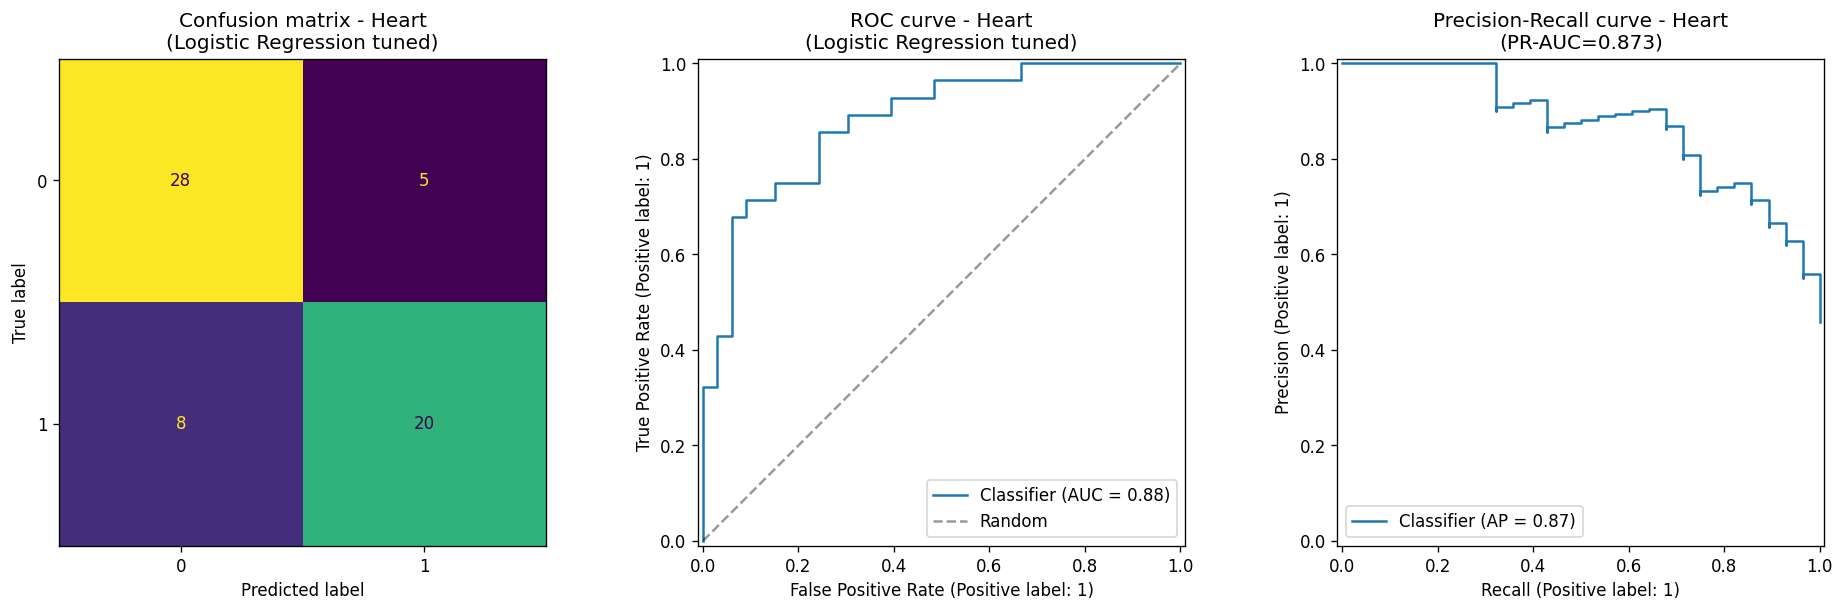

In [22]:
best_name_heart  = results_heart.iloc[0]["Modele"]
best_model_heart = models_heart[best_name_heart]
best_model_heart.fit(Xh_train, yh_train)

yh_true_medical = binary_medical_labels(yh_test, positive_label=0)
yh_proba_maladie = positive_proba(best_model_heart, Xh_test, positive_label=0)
yh_pred_maladie = (yh_proba_maladie >= 0.5).astype(int)

print(f"Best heart model: {best_name_heart}")
print("\nMedical classification report (1 = heart disease detected):")
print(classification_report(yh_true_medical, yh_pred_maladie, target_names=["Not sick", "Sick"], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(yh_true_medical, yh_pred_maladie, ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix - Heart\n({best_name_heart})")

RocCurveDisplay.from_predictions(yh_true_medical, yh_proba_maladie, ax=axes[1])
axes[1].set_title(f"ROC curve - Heart\n({best_name_heart})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Random")
axes[1].legend()

PrecisionRecallDisplay.from_predictions(yh_true_medical, yh_proba_maladie, ax=axes[2])
axes[2].set_title(f"Precision-Recall curve - Heart\n(PR-AUC={average_precision_score(yh_true_medical, yh_proba_maladie):.3f})")

plt.tight_layout()
plt.show()


### Optimisation du seuil - Heart

Pour `heart`, on utilise la probabilite de maladie `P(target=0)`.  
Le tableau ci-dessous montre l'effet du seuil sur les faux negatifs et le rappel des patients malades.


In [23]:
heart_thresholds = threshold_analysis(yh_true_medical, yh_proba_maladie)
display(heart_thresholds.style.highlight_max(subset=["Recall", "F1-Score"], color="#d4edda")
        .highlight_min(subset=["False negatives"], color="#d4edda")
        .format({"Threshold": "{:.2f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "Specificity": "{:.4f}", "F1-Score": "{:.4f}"}))

heart_candidates = heart_thresholds[heart_thresholds["Recall"] >= 0.80]
heart_threshold_choice = heart_candidates.sort_values(["False negatives", "False positives"]).iloc[0] if len(heart_candidates) else None
if heart_threshold_choice is not None:
    print("Recommended threshold when recall is the priority:")
    display(heart_threshold_choice.to_frame().T)
else:
    print("No tested threshold reaches the target recall of 0.80.")


,Threshold,Precision,Recall,Specificity,F1-Score,False positives,False negatives,True positives,True negatives
0,0.30,0.6190,0.9286,0.5152,0.7429,16,2,26,17
1,0.35,0.6579,0.8929,0.6061,0.7576,13,3,25,20
2,0.40,0.7500,0.8571,0.7576,0.8000,8,4,24,25
3,0.45,0.7500,0.7500,0.7879,0.7500,7,7,21,26
4,0.50,0.8000,0.7143,0.8485,0.7547,5,8,20,28
5,0.55,0.8000,0.7143,0.8485,0.7547,5,8,20,28
6,0.60,0.8636,0.6786,0.9091,0.7600,3,9,19,30


Recommended threshold when recall is the priority:


,Threshold,Precision,Recall,Specificity,F1-Score,False positives,False negatives,True positives,True negatives
0,0.3,0.619,0.9286,0.5152,0.7429,16.0,2.0,26.0,17.0


### Lecture du test de seuil Heart

Ce test observe comment le seuil modifie la detection des patients malades dans le dataset Heart.  
Comme le dataset est petit, une seule erreur peut changer fortement les pourcentages : il faut donc regarder a la fois les metriques et les nombres bruts de faux positifs/faux negatifs.

Le meilleur seuil n'est pas forcement celui qui maximise l'accuracy. Dans un contexte medical, on cherche surtout a limiter les faux negatifs tout en gardant un nombre raisonnable de fausses alertes.


### Importance des variables - Heart


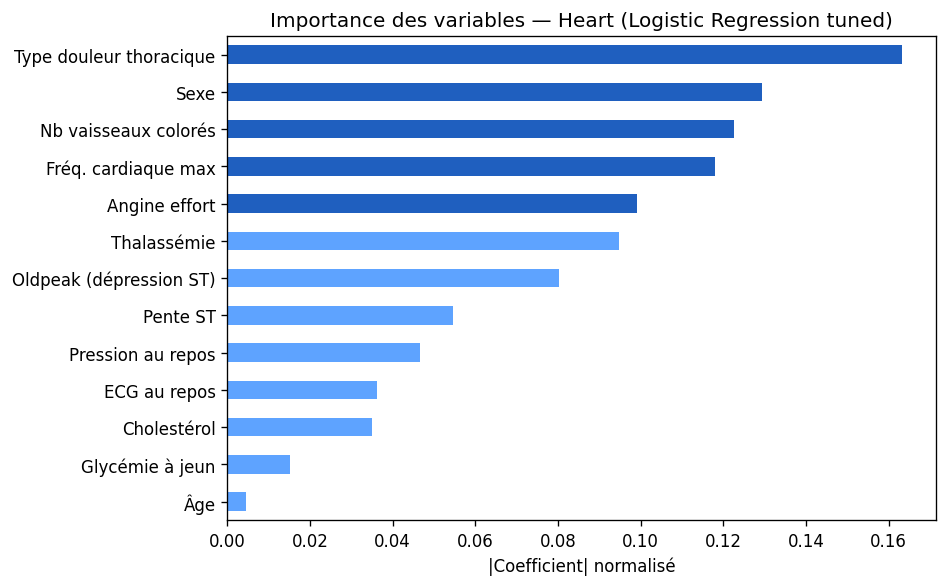

In [24]:
labels_fr_heart = {
    "age":"Âge","sex":"Sexe","cp":"Type douleur thoracique",
    "trestbps":"Pression au repos","chol":"Cholestérol",
    "fbs":"Glycémie à jeun","restecg":"ECG au repos",
    "thalach":"Fréq. cardiaque max","exang":"Angine effort",
    "oldpeak":"Oldpeak (dépression ST)","slope":"Pente ST",
    "ca":"Nb vaisseaux colorés","thal":"Thalassémie"
}
feature_names_heart_fr = [labels_fr_heart.get(f, f) for f in X_heart.columns]

plot_feature_importance(best_model_heart, feature_names_heart_fr,
                        f"Importance des variables — Heart ({best_name_heart})")

### Interpretabilite complementaire - Heart

L'importance par permutation verifie quelles variables degradent le plus la performance lorsqu'elles sont melangees.  
Elle complete les coefficients de la regression logistique, car elle mesure l'impact sur la prediction finale.


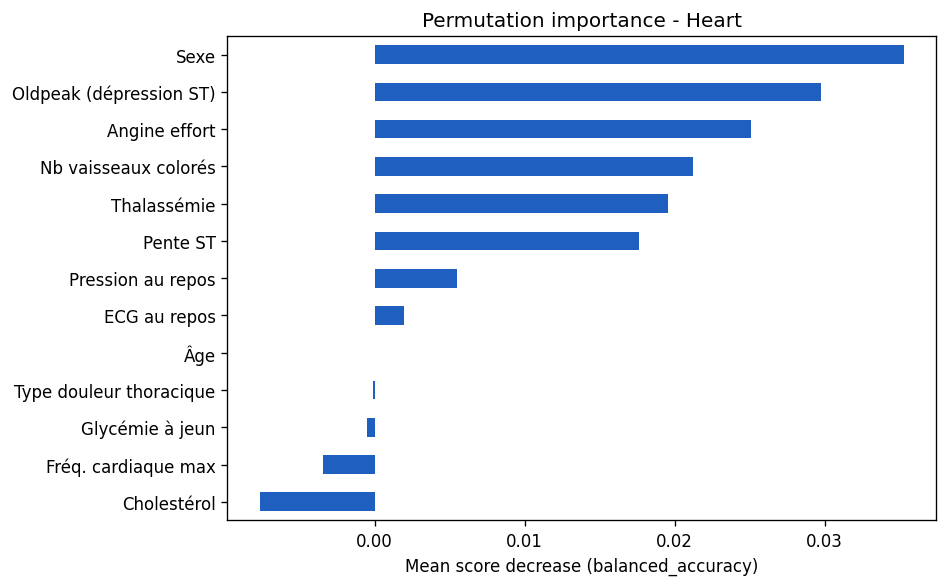

In [25]:
plot_permutation_importance(
    best_model_heart,
    Xh_test,
    yh_test,
    feature_names_heart_fr,
    "Permutation importance - Heart",
    scoring="balanced_accuracy"
)


## 13. Synthese des seuils retenus

Cette section resume les seuils qui reduisent les faux negatifs tout en gardant une precision acceptable.  
Le seuil `0.5` est simple a expliquer, mais il n'est pas toujours optimal dans un contexte sante.


In [26]:
summary_thresholds = pd.DataFrame([
    {
        "Dataset": "Cardio",
        "Modele": best_name_cardio,
        "Threshold 0.5 - FN": int(confusion_matrix(yc_true_medical, yc_pred, labels=[0, 1]).ravel()[2]),
        "Best threshold recall>=0.75": cardio_threshold_choice["Threshold"] if 'cardio_threshold_choice' in globals() and cardio_threshold_choice is not None else np.nan,
    },
    {
        "Dataset": "Heart",
        "Modele": best_name_heart,
        "Threshold 0.5 - FN": int(confusion_matrix(yh_true_medical, yh_pred_maladie, labels=[0, 1]).ravel()[2]),
        "Best threshold recall>=0.80": heart_threshold_choice["Threshold"] if 'heart_threshold_choice' in globals() and heart_threshold_choice is not None else np.nan,
    }
])
display(summary_thresholds)


,Dataset,Modele,Threshold 0.5 - FN,Best threshold recall>=0.75,Best threshold recall>=0.80
0,Cardio,Random Forest tuned,2225,0.3,NaN
1,Heart,Logistic Regression tuned,8,NaN,0.3


### Lecture de la synthese des seuils

Cette synthese rassemble les informations importantes pour comparer le seuil par defaut et les seuils orientes rappel.  
Elle sert a justifier clairement le choix final dans le rapport : soit garder 0.5 pour la simplicite, soit proposer un seuil plus bas pour reduire les faux negatifs.

Le choix final doit rester explique comme un compromis. Un seuil n'est pas uniquement une decision mathematique : dans un sujet de sante, il depend aussi du risque que l'on accepte entre fausse alerte et malade non detecte.


## 14. Conclusion ML renforcee

### Main decisions

| Topic | Decision |
|------|----------|
| Main dataset | `cardio`, because it contains 70,000 observations and accessible variables |
| Secondary dataset | `heart`, smaller but clinically richer |
| Main Cardio model | Random Forest, with a tuned version compared in the notebook |
| Main Heart model | Logistic Regression, more stable on a small dataset |
| Medical positive class | Cardio: `target=1`; Heart: `target=0` because the Kaggle encoding is inverted |

### Evaluation improvements

The evaluation no longer relies only on accuracy. For a health-related task, the notebook also tracks:

- **recall**, to measure detection of sick profiles;
- **false negatives**, the most sensitive medical errors;
- **specificity**, to measure recognition of non-sick profiles;
- **PR-AUC**, to analyze the precision / recall tradeoff;
- the effect of several **decision thresholds**.

### Medical reading of the threshold

The threshold `0.5` remains convenient for the website because it is simple to explain.  
However, the notebook shows that a lower threshold can increase recall and reduce false negatives, at the cost of more false positives.

In a real medical system, this threshold should be selected with healthcare professionals according to the clinical cost of errors.

### Interpretability

Two interpretation levels are used:

- internal model importance: coefficients or Gini importance;
- permutation importance: real impact of a variable on predictive performance.

This avoids relying on a single importance indicator.

### Limits

- The datasets are public and do not represent all real medical diversity.
- The Heart dataset is small after deduplication, so metrics must be interpreted carefully.
- Cardio outliers are documented but not systematically removed.
- The model gives a statistical estimate, not a diagnosis.

### Integration in CardioPredict

The models can still be exported to JSON and integrated through `site/ml/predict.py`.  
The notebook now also justifies metric choices, threshold analysis and interpretability for the final report.


